# Embedding Model Benchmark Pipeline

This notebook consolidates the main stages required for the article experiments:

1. embedding generation;
2. embedding loading;
3. optional PCA dimensionality reduction;
4. **R(k)** computation;
5. **k-NN MAE** computation;
6. collection of computational metrics.

The model list is defined **once** in the configuration section.

## Outputs

The pipeline stores:

- one embedding per court case;
- inference time per judgment;
- model metadata;
- `R(k)` and `MAE` for each model and value of `k`;
- consolidated CSV tables for later use in the article.

## Dataset schema

The pipeline assumes that `base_consolidada.csv` contains at least the following source columns:

- `numero_processo`;
- `crime`;
- `pena_def_em_dias`.

These field names are preserved in Portuguese because they belong to the original dataset schema. If they are produced by an upstream preprocessing script, that script is also required for full reproducibility.

In [1]:
from sentence_transformers import SentenceTransformer

import gc
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from tqdm.auto import tqdm
from sklearn.decomposition import PCA
from sklearn.preprocessing import Normalizer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

## 1. Configuration

To add, remove, or replace models, edit only `MODELS` and `ACTIVE_MODELS`.

The initial models were selected to represent different profiles:

- **Legal-BERTimbau**: a Portuguese model adapted to the legal domain;
- **Multilingual E5 Base**: a general-purpose multilingual embedding model;
- **Multilingual MiniLM**: a smaller alternative useful for studying the trade-off between representation quality and computational cost.

E5 uses the `query: ` prefix because the E5 family requires task prefixes and recommends `query:` for symmetric semantic-similarity tasks.

In [ ]:
# Models

MODELS = {
    "legalbr": {
        "hf_name": "rufimelo/Legal-BERTimbau-sts-large-ma-v3",
        "folder": "embeddings_legalbr",
        "prefix": "",
    },
    "e5_base": {
        "hf_name": "intfloat/multilingual-e5-base",
        "folder": "embeddings_e5_base",
        "prefix": "query: ",
    },
    "minilm_multi": {
        "hf_name": "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
        "folder": "embeddings_minilm_multi",
        "prefix": "",
    },
}

ACTIVE_MODELS = [
    "legalbr",
    "e5_base",
    "minilm_multi",
]


SENTENCE_DAYS_COLUMN = "pena_def_em_dias"

# Initially keeps the crime used as the focus of the final undergraduate-thesis experiment.
# To test additional crimes, add them to the list.
TARGET_CRIMES = [
    "Furto simples",
    # "Furto qualificado",
    # "Roubo",
    # "Trafico de drogas",
]

K_VALUES = [3, 5, 10, 20, 30, 50, 70, 100, 120, 150]

# Keeps the dimensionality reduction used in the original notebook.
# Use None to evaluate embeddings without PCA.
PCA_COMPONENTS = 100

# The original code used approximately 450 tokens with an overlap of 100.
# For models with a smaller context window, the size is reduced automatically
# and the overlap is kept proportional.
MAX_CHUNK_TOKENS = 450
OVERLAP_RATIO = 100 / 450

# Number of chunks processed simultaneously by SentenceTransformer.
# If an OOM error occurs, reduce this value to 4 or 2.
BATCH_SIZE_CHUNKS = 8

# False = reuse existing embeddings.
# True = overwrite all embeddings and reset the timing log.
# For a fair timing comparison, run all models once with True.
FORCE_REGENERATION = False

RANDOM_STATE = 42

device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA A100 80GB PCIe


## 2. Automatic Project-Root Detection

The original notebooks used different relative path depths (`../` and `../../`). To avoid path inconsistencies, the function below searches parent directories for:

`dataset/datasets_texto/base_consolidada.csv`

The Portuguese directory and file names are kept for compatibility with the original dataset layout. If automatic detection fails, set `PROJECT_ROOT` manually.

In [3]:
def find_project_root():
    cwd = Path.cwd().resolve()

    candidates = [cwd] + list(cwd.parents)

    for candidate in candidates:
        file_path = candidate / "dataset" / "datasets_texto" / "base_consolidada.csv"
        if file_path.exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root automatically. "
        "Set PROJECT_ROOT manually."
    )


PROJECT_ROOT = find_project_root()

DATASET_DIR = PROJECT_ROOT / "dataset" / "datasets_texto"
SENTENCES_DIR = DATASET_DIR / "sentencas_preprocessadas"
EMBEDDINGS_DIR = DATASET_DIR / "embeddings"

OUTPUT_DIR = PROJECT_ROOT / "output" / "benchmark_embeddings"
TIMINGS_DIR = OUTPUT_DIR / "timings"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TIMINGS_DIR.mkdir(parents=True, exist_ok=True)
EMBEDDINGS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_DIR:", DATASET_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

PROJECT_ROOT: /home/dfrobson/Elias/JURIX 2026/Codigo/Original/tcc/extracao_sentencas
DATASET_DIR: /home/dfrobson/Elias/JURIX 2026/Codigo/Original/tcc/extracao_sentencas/dataset/datasets_texto
OUTPUT_DIR: /home/dfrobson/Elias/JURIX 2026/Codigo/Original/tcc/extracao_sentencas/output/benchmark_embeddings


## 3. Corpus Loading

This stage replaces the duplicated corpus-loading logic from the original experiment notebook.

Court-case identifiers are associated with text files using `Path.stem`, which works on both Windows and Linux.

In [4]:
sentence_files = [f for f in SENTENCES_DIR.iterdir() if f.is_file()]

df_sentence_files = pd.DataFrame({
    "numero_processo": [f.stem for f in sentence_files],
    "path": sentence_files,
})

df_consolidated = pd.read_csv(DATASET_DIR / "base_consolidada.csv")

required_columns = {
    "numero_processo",
    "crime",
    SENTENCE_DAYS_COLUMN,
}

missing_columns = required_columns - set(df_consolidated.columns)

if missing_columns:
    raise ValueError(
        "Required columns missing from base_consolidada.csv: "
        + ", ".join(sorted(missing_columns))
        + ". The code that creates these columns is required."
    )

df_consolidated["numero_processo"] = df_consolidated["numero_processo"].astype(str)
df_sentence_files["numero_processo"] = df_sentence_files["numero_processo"].astype(str)

df_consolidated = df_consolidated.merge(
    df_sentence_files,
    how="left",
    on="numero_processo",
)

missing_paths = int(df_consolidated["path"].isna().sum())

if missing_paths:
    print(
        f"Warning: {missing_paths} judgment(s) have no matching file "
        "and will be removed from the pipeline."
    )
    df_consolidated = df_consolidated.dropna(subset=["path"]).copy()


def read_sentence(path):
    with open(path, mode="r", encoding="cp1252") as f:
        return f.read()


df_consolidated["corpus"] = [
    read_sentence(path)
    for path in tqdm(
        df_consolidated["path"],
        desc="Reading judgments",
        unit="file",
    )
]

print(f"Available judgments: {len(df_consolidated)}")

Reading judgments:   0%|          | 0/4630 [00:00<?, ?file/s]

Available judgments: 4630


## 4. Embedding Generation Functions

The core behavior of the original implementation is preserved:

1. tokenize the document;
2. split it into chunks;
3. generate a normalized embedding for each chunk;
4. average the chunk embeddings into a document representation.

The main difference is that the model is now passed as a parameter.

The effective chunk size respects `model.max_seq_length`, which is important because different SentenceTransformer models may have different sequence-length limits.

In [5]:
def get_model_limit(model):
    max_seq = getattr(model, "max_seq_length", None)

    if max_seq is None or max_seq <= 0 or max_seq > 1_000_000:
        max_seq = getattr(model.tokenizer, "model_max_length", 512)

    if max_seq is None or max_seq <= 0 or max_seq > 1_000_000:
        max_seq = 512

    return int(max_seq)


def compute_chunking(model, prefix=""):
    max_seq_length = get_model_limit(model)

    special_tokens = model.tokenizer.num_special_tokens_to_add(pair=False)

    prefix_tokens = 0
    if prefix:
        prefix_tokens = len(
            model.tokenizer.encode(
                prefix,
                add_special_tokens=False,
                verbose=False,
            )
        )

    chunk_size = min(
        MAX_CHUNK_TOKENS,
        max_seq_length - special_tokens - prefix_tokens,
    )

    if chunk_size <= 0:
        raise ValueError(
            f"Invalid chunk size ({chunk_size}) for the model."
        )

    overlap = int(round(chunk_size * OVERLAP_RATIO))
    overlap = min(overlap, chunk_size - 1)

    return {
        "max_seq_length": max_seq_length,
        "chunk_size": chunk_size,
        "overlap": overlap,
    }


def chunk_text(text, model, chunk_size, overlap):
    tokens = model.tokenizer.encode(
        text,
        add_special_tokens=False,
        verbose=False,
    )

    step = chunk_size - overlap

    chunks = []

    for i in range(0, len(tokens), step):
        chunk_tokens = tokens[i:i + chunk_size]

        chunk_text_value = model.tokenizer.decode(
            chunk_tokens,
            skip_special_tokens=True,
        )

        chunks.append(chunk_text_value)

    # Safeguard for empty texts.
    if not chunks:
        chunks = [""]

    return chunks


def get_document_embedding(
    text,
    model,
    prefix,
    chunk_size,
    overlap,
):
    chunks = chunk_text(
        text=text,
        model=model,
        chunk_size=chunk_size,
        overlap=overlap,
    )

    model_texts = [
        f"{prefix}{chunk}"
        for chunk in chunks
    ]

    embeddings = model.encode(
        model_texts,
        normalize_embeddings=True,
        show_progress_bar=False,
        batch_size=BATCH_SIZE_CHUNKS,
    )

    document_embedding = np.mean(
        embeddings,
        axis=0,
    )

    return document_embedding, len(chunks)

## 5. Persistence and Computational Metrics

Each embedding is stored individually as a `.txt` file, allowing interrupted runs to be resumed.

A timing record is also stored for every processed judgment. This enables the computation of:

- total inference time;
- mean and median inference time per judgment;
- documents processed per minute;
- mean number of chunks per document.

The pipeline also collects:

- number of parameters;
- parameter memory footprint;
- embedding dimensionality;
- maximum sequence length;
- peak VRAM usage.

> The reported model size in MB refers to the loaded parameter tensors, not to the total size of the Hugging Face repository.

In [6]:
def save_embedding(process_id, embedding, folder):
    folder.mkdir(parents=True, exist_ok=True)

    file_path = folder / f"{process_id}.txt"

    with open(file_path, mode="w", encoding="utf-8") as f:
        f.write(",".join(str(float(v)) for v in embedding))


def append_timing(timing_file, record):
    df_record = pd.DataFrame([record])

    df_record.to_csv(
        timing_file,
        mode="a",
        header=not timing_file.exists(),
        index=False,
    )


def model_parameter_stats(model):
    params = list(model.parameters())

    num_params = sum(p.numel() for p in params)

    param_bytes = sum(
        p.numel() * p.element_size()
        for p in params
    )

    return {
        "parameters": int(num_params),
        "parameters_millions": num_params / 1e6,
        "parameter_size_mb": param_bytes / (1024 ** 2),
    }


def generate_model_embeddings(
    dataset,
    model_id,
    cfg,
    force_regeneration=False,
):
    print("\n" + "=" * 80)
    print(f"Model: {model_id}")
    print(cfg["hf_name"])
    print("=" * 80)

    folder = EMBEDDINGS_DIR / cfg["folder"]
    folder.mkdir(parents=True, exist_ok=True)

    timing_file = TIMINGS_DIR / f"{model_id}.csv"

    if force_regeneration and timing_file.exists():
        timing_file.unlink()

    load_start = time.perf_counter()

    model = SentenceTransformer(
        cfg["hf_name"],
        cache_folder=str(PROJECT_ROOT / ".cache"),
        device=device,
    )

    load_time = time.perf_counter() - load_start

    chunk_cfg = compute_chunking(
        model=model,
        prefix=cfg.get("prefix", ""),
    )

    param_stats = model_parameter_stats(model)

    embedding_dim = model.get_sentence_embedding_dimension()

    print(f"Embedding dimension: {embedding_dim}")
    print(f"Max sequence length: {chunk_cfg['max_seq_length']}")
    print(f"Chunk efetivo: {chunk_cfg['chunk_size']}")
    print(f"Overlap efetivo: {chunk_cfg['overlap']}")
    print(f"Parameters: {param_stats['parameters_millions']:.1f} M")

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    ids = dataset["numero_processo"].astype(str)

    if force_regeneration:
        pending = pd.Series(
            True,
            index=dataset.index,
        )
    else:
        existing = {
            f.stem
            for f in folder.iterdir()
            if f.is_file() and f.suffix == ".txt"
        }

        pending = ~ids.isin(existing)

    indices = dataset.index[pending]

    print(
        f"Existing: {len(dataset) - len(indices)} | "
        f"To process: {len(indices)}"
    )

    run_start = time.perf_counter()

    for idx in tqdm(
        indices,
        total=len(indices),
        desc=f"Generating {model_id}",
        unit="judgment",
    ):
        process_id = str(
            dataset.at[idx, "numero_processo"]
        )

        text = dataset.at[idx, "corpus"]

        item_start = time.perf_counter()

        embedding, n_chunks = get_document_embedding(
            text=text,
            model=model,
            prefix=cfg.get("prefix", ""),
            chunk_size=chunk_cfg["chunk_size"],
            overlap=chunk_cfg["overlap"],
        )

        inference_time = time.perf_counter() - item_start

        save_embedding(
            process_id=process_id,
            embedding=embedding,
            folder=folder,
        )

        append_timing(
            timing_file,
            {
                "model_id": model_id,
                "numero_processo": process_id,
                "inference_time_s": inference_time,
                "n_chunks": n_chunks,
            },
        )

    current_run_time = time.perf_counter() - run_start

    peak_vram_mb = np.nan

    if torch.cuda.is_available():
        peak_vram_mb = (
            torch.cuda.max_memory_allocated()
            / (1024 ** 2)
        )

    metadata = {
        "model_id": model_id,
        "hf_model": cfg["hf_name"],
        "device": device,
        "gpu": (
            torch.cuda.get_device_name(0)
            if torch.cuda.is_available()
            else ""
        ),
        "embedding_dimension": embedding_dim,
        "max_seq_length": chunk_cfg["max_seq_length"],
        "effective_chunk_size": chunk_cfg["chunk_size"],
        "effective_overlap": chunk_cfg["overlap"],
        "parameters": param_stats["parameters"],
        "parameters_millions": param_stats["parameters_millions"],
        "parameter_size_mb": param_stats["parameter_size_mb"],
        "load_time_current_run_s": load_time,
        "documents_processed_current_run": len(indices),
        "total_time_current_run_s": current_run_time,
        "peak_vram_current_run_mb": peak_vram_mb,
    }

    del model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metadata

## 6. Embedding Generation for All Active Models

If execution is interrupted, rerun the notebook with `FORCE_REGENERATION = False`. Embeddings that already exist will be skipped.

For a fair timing comparison in the article, run all models once with `FORCE_REGENERATION = True` while avoiding other substantial GPU workloads.

In [7]:
run_metadata = []

for model_id in ACTIVE_MODELS:
    metadata = generate_model_embeddings(
        dataset=df_consolidated,
        model_id=model_id,
        cfg=MODELS[model_id],
        force_regeneration=FORCE_REGENERATION,
    )

    run_metadata.append(metadata)

df_metadata = pd.DataFrame(run_metadata)

df_metadata.to_csv(
    OUTPUT_DIR / "model_metadata.csv",
    index=False,
)

df_metadata


Model: legalbr
rufimelo/Legal-BERTimbau-sts-large-ma-v3


Invalid model-index. Not loading eval results into CardData.


Embedding dimension: 1024
Max sequence length: 512
Chunk efetivo: 450
Overlap efetivo: 100
Parameters: 334.4 M
Existing: 4630 | To process: 0


Generating legalbr: 0judgment [00:00, ?judgment/s]


Model: e5_base
intfloat/multilingual-e5-base
Embedding dimension: 768
Max sequence length: 512
Chunk efetivo: 450
Overlap efetivo: 100
Parameters: 278.0 M
Existing: 4630 | To process: 0


Generating e5_base: 0judgment [00:00, ?judgment/s]


Model: minilm_multi
sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Embedding dimension: 384
Max sequence length: 128
Chunk efetivo: 126
Overlap efetivo: 28
Parameters: 117.7 M
Existing: 4630 | To process: 0


Generating minilm_multi: 0judgment [00:00, ?judgment/s]

,model_id,hf_model,device,gpu,embedding_dimension,max_seq_length,effective_chunk_size,effective_overlap,parameters,parameters_millions,parameter_size_mb,load_time_current_run_s,documents_processed_current_run,total_time_current_run_s,peak_vram_current_run_mb
0,legalbr,rufimelo/Legal-BERTimbau-sts-large-ma-v3,cuda,NVIDIA A100 80GB PCIe,1024,512,450,100,334396416,334.396416,1275.621094,3.981620,0,0.008501,1275.628906
1,e5_base,intfloat/multilingual-e5-base,cuda,NVIDIA A100 80GB PCIe,768,512,450,100,278043648,278.043648,1060.652344,4.717157,0,0.010234,1060.727539
2,minilm_multi,sentence-transformers/paraphrase-multilingual-...,cuda,NVIDIA A100 80GB PCIe,384,128,126,28,117653760,117.653760,448.813477,3.107983,0,0.008119,448.821289


## 7. Timing Consolidation

Timing information is aggregated from the per-judgment logs.

If embeddings were created by an earlier script but no corresponding timing log exists, timing coverage will be below 100%. For a fair computational comparison, regenerate that model once under the benchmark pipeline.

In [ ]:
def consolidate_timings(model_id):
    file_path = TIMINGS_DIR / f"{model_id}.csv"

    if not file_path.exists():
        return {
            "model_id": model_id,
            "documents_with_timing": 0,
            "total_inference_time_s": np.nan,
            "mean_time_per_doc_s": np.nan,
            "median_time_per_doc_s": np.nan,
            "docs_per_minute": np.nan,
            "mean_chunks_per_doc": np.nan,
        }

    df_t = pd.read_csv(file_path)

    # If the run is resumed or repeated, keep the most recent record
    # for each case.
    df_t["numero_processo"] = df_t["numero_processo"].astype(str)

    df_t = df_t.drop_duplicates(
        subset=["numero_processo"],
        keep="last",
    )

    total_s = df_t["inference_time_s"].sum()
    n = len(df_t)

    return {
        "model_id": model_id,
        "documents_with_timing": n,
        "total_inference_time_s": total_s,
        "mean_time_per_doc_s": df_t["inference_time_s"].mean(),
        "median_time_per_doc_s": df_t["inference_time_s"].median(),
        "docs_per_minute": (
            (n / total_s) * 60
            if total_s > 0
            else np.nan
        ),
        "mean_chunks_per_doc": df_t["n_chunks"].mean(),
    }


df_timings = pd.DataFrame([
    consolidate_timings(model_id)
    for model_id in ACTIVE_MODELS
])

df_performance = df_metadata.merge(
    df_timings,
    on="model_id",
    how="left",
)

df_performance["timing_coverage_pct"] = (
    df_performance["documents_with_timing"]
    / len(df_consolidated)
    * 100
)

table_columns = [
    "model_id",
    "parameters_millions",
    "parameter_size_mb",
    "embedding_dimension",
    "max_seq_length",
    "effective_chunk_size",
    "total_inference_time_s",
    "mean_time_per_doc_s",
    "median_time_per_doc_s",
    "docs_per_minute",
    "peak_vram_current_run_mb",
    "timing_coverage_pct",
]

performance_table = df_performance[table_columns].copy()

performance_table.to_csv(
    OUTPUT_DIR / "model_performance_table.csv",
    index=False,
)

performance_table

## 8. Intersection of Available Cases

For a fair comparison, all models are evaluated on exactly the same set of court cases.

If any model has missing embeddings, the evaluation set is restricted to the intersection of cases available for all models.

In [9]:
def ids_with_embeddings(model_id):
    cfg = MODELS[model_id]
    folder = EMBEDDINGS_DIR / cfg["folder"]

    return {
        f.stem
        for f in folder.iterdir()
        if f.is_file() and f.suffix == ".txt"
    }


common_ids = set(
    df_consolidated["numero_processo"].astype(str)
)

for model_id in ACTIVE_MODELS:
    common_ids &= ids_with_embeddings(model_id)

df_evaluation = df_consolidated[
    df_consolidated["numero_processo"]
    .astype(str)
    .isin(common_ids)
].copy()

df_evaluation = df_evaluation.reset_index(drop=True)

print(
    f"Cases in dataset: {len(df_consolidated)}"
)

print(
    f"Cases available for ALL models: "
    f"{len(df_evaluation)}"
)

Cases in dataset: 4630
Cases available for ALL models: 4630


## 9. Loading Embedding Matrices

Embeddings are loaded in exactly the same row order as `df_evaluation`.

In [10]:
def load_embedding_matrix(
    dataset,
    model_id,
):
    cfg = MODELS[model_id]

    folder = EMBEDDINGS_DIR / cfg["folder"]

    matrix = []

    for process_id in tqdm(
        dataset["numero_processo"].astype(str),
        desc=f"Loading {model_id}",
        unit="embedding",
    ):
        file_path = folder / f"{process_id}.txt"

        vector = np.fromstring(
            file_path.read_text(encoding="utf-8"),
            sep=",",
            dtype=float,
        )

        matrix.append(vector)

    return np.stack(matrix)


embedding_matrices = {
    model_id: load_embedding_matrix(
        df_evaluation,
        model_id,
    )
    for model_id in ACTIVE_MODELS
}

for model_id, matrix in embedding_matrices.items():
    print(model_id, matrix.shape)

Loading legalbr:   0%|          | 0/4630 [00:00<?, ?embedding/s]

Loading e5_base:   0%|          | 0/4630 [00:00<?, ?embedding/s]

Loading minilm_multi:   0%|          | 0/4630 [00:00<?, ?embedding/s]

legalbr (4630, 1024)
e5_base (4630, 768)
minilm_multi (4630, 384)


## 10. R(k) and MAE Using the Same Neighbor Ranking

For each model and crime:

1. filter judgments belonging to the target crime;
2. optionally apply PCA when `PCA_COMPONENTS` is not `None`;
3. L2-normalize the vectors;
4. compute the cosine-similarity matrix once;
5. rank the nearest neighbors once;
6. reuse the same ranking for all values of `k`.

### R(k)

The metric follows the definition introduced in the undergraduate thesis:

\[
R(k)=\frac{\text{mean variance of penalties within local neighborhoods}}
{\text{global penalty variance for the crime}}
\]

Lower values indicate more homogeneous penalties among nearby judgments.

### MAE

For each judgment, the estimated penalty is the mean penalty among its `k` nearest neighbors:

\[
\hat{p_i} = \frac{1}{k}\sum_{j \in N_k(i)}p_j
\]

and:

\[
MAE = \frac{1}{N}\sum_i |p_i-\hat{p_i}|
\]

Lower values are better.

As a reference, the notebook also computes a **constant baseline** that always predicts the median penalty for the crime. `MAE_reduction_vs_baseline_pct` reports the relative improvement or deterioration of embedding-based k-NN compared with this baseline.

In [11]:
def prepare_representation(
    X,
    pca_components=PCA_COMPONENTS,
):
    X_out = X

    pca_used = None

    if pca_components is not None:
        n_components = min(
            pca_components,
            X.shape[0] - 1,
            X.shape[1],
        )

        if n_components >= 1:
            pca = PCA(
                n_components=n_components,
                random_state=RANDOM_STATE,
            )

            X_out = pca.fit_transform(X_out)
            pca_used = n_components

    normalizer = Normalizer()

    X_out = normalizer.fit_transform(X_out)

    return X_out, pca_used


def evaluate_model_crime(
    dataset,
    matriz_embeddings,
    model_id,
    crime,
    k_values,
):
    mask = (
        dataset["crime"]
        .astype(str)
        .eq(crime)
        .to_numpy()
    )

    df_crime = dataset.loc[mask].reset_index(drop=True)
    X = matriz_embeddings[mask]

    penalty_days = (
        df_crime[SENTENCE_DAYS_COLUMN]
        .astype(float)
        .to_numpy()
    )

    n = len(df_crime)

    if n < 2:
        print(
            f"Warning: {crime} has fewer than two judgments "
            f"for {model_id}."
        )
        return []

    X_rep, pca_used = prepare_representation(
        X,
        pca_components=PCA_COMPONENTS,
    )

    sim_matrix = cosine_similarity(X_rep)

    np.fill_diagonal(
        sim_matrix,
        -np.inf,
    )

    # Descending similarity ranking.
    neighbor_ranking = np.argsort(
        -sim_matrix,
        axis=1,
    )

    global_var = np.var(penalty_days)

    # Constant MAE baseline: median sentence length for the crime.
    baseline_penalty = np.median(penalty_days)
    mae_baseline_days = np.mean(
        np.abs(penalty_days - baseline_penalty)
    )

    results = []

    for k in k_values:
        if k >= n:
            print(
                f"Skipping k={k} for {model_id}/{crime}: "
                f"only {n} judgments are available."
            )
            continue

        neighbors = neighbor_ranking[:, :k]

        neighbor_penalty_days = penalty_days[neighbors]

        # R(k)
        local_variances = np.var(
            neighbor_penalty_days,
            axis=1,
        )

        mean_local_variance = np.mean(
            local_variances
        )

        r_k = (
            mean_local_variance / global_var
            if global_var > 0
            else np.nan
        )

        # Simple k-NN regression: mean penalty length among neighbors.
        predicted_penalty_days = np.mean(
            neighbor_penalty_days,
            axis=1,
        )

        mae_days = np.mean(
            np.abs(
                penalty_days - predicted_penalty_days
            )
        )

        results.append({
            "model_id": model_id,
            "hf_model": MODELS[model_id]["hf_name"],
            "crime": crime,
            "n_sentences": n,
            "k": k,
            "pca_components": pca_used,
            "R_k": r_k,
            "MAE_days": mae_days,
            "MAE_months_approx": mae_days / 30,
            "MAE_baseline_days": mae_baseline_days,
            "MAE_reduction_vs_baseline_pct": (
                (1 - mae_days / mae_baseline_days) * 100
                if mae_baseline_days > 0
                else np.nan
            ),
            "global_variance": global_var,
            "mean_local_variance": mean_local_variance,
        })

    return results

## 11. Evaluation

In [12]:
results = []

for model_id in ACTIVE_MODELS:
    for crime in TARGET_CRIMES:
        print(
            f"Evaluating {model_id} | {crime}"
        )

        results.extend(
            evaluate_model_crime(
                dataset=df_evaluation,
                matriz_embeddings=embedding_matrices[model_id],
                model_id=model_id,
                crime=crime,
                k_values=K_VALUES,
            )
        )

df_metrics = pd.DataFrame(results)

df_metrics.to_csv(
    OUTPUT_DIR / "rk_mae_metrics.csv",
    index=False,
)

df_metrics

Evaluating legalbr | Furto simples
Evaluating e5_base | Furto simples
Evaluating minilm_multi | Furto simples


,model_id,hf_model,crime,n_sentences,k,pca_components,R_k,MAE_days,MAE_months_approx,MAE_baseline_days,MAE_reduction_vs_baseline_pct,global_variance,mean_local_variance
0,legalbr,rufimelo/Legal-BERTimbau-sts-large-ma-v3,Furto simples,1942,3,100,0.639360,121.106591,4.036886,122.013903,0.743614,28978.077078,18527.417897
1,legalbr,rufimelo/Legal-BERTimbau-sts-large-ma-v3,Furto simples,1942,5,100,0.781778,116.867147,3.895572,122.013903,4.218172,28978.077078,22654.422987
2,legalbr,rufimelo/Legal-BERTimbau-sts-large-ma-v3,Furto simples,1942,10,100,0.873594,112.503965,3.750132,122.013903,7.794143,28978.077078,25315.085350
3,legalbr,rufimelo/Legal-BERTimbau-sts-large-ma-v3,Furto simples,1942,20,100,0.941718,110.932415,3.697747,122.013903,9.082152,28978.077078,27289.168475
4,legalbr,rufimelo/Legal-BERTimbau-sts-large-ma-v3,Furto simples,1942,30,100,0.952235,110.489461,3.682982,122.013903,9.445188,28978.077078,27593.947853
5,legalbr,rufimelo/Legal-BERTimbau-sts-large-ma-v3,Furto simples,1942,50,100,0.981390,110.659732,3.688658,122.013903,9.305637,28978.077078,28438.787917
6,legalbr,rufimelo/Legal-BERTimbau-sts-large-ma-v3,Furto simples,1942,70,100,0.992804,110.953119,3.698437,122.013903,9.065183,28978.077078,28769.541408
7,legalbr,rufimelo/Legal-BERTimbau-sts-large-ma-v3,Furto simples,1942,100,100,1.002686,111.290510,3.709684,122.013903,8.788665,28978.077078,29055.904072
8,legalbr,rufimelo/Legal-BERTimbau-sts-large-ma-v3,Furto simples,1942,120,100,1.006557,111.699245,3.723308,122.013903,8.453675,28978.077078,29168.080274
9,legalbr,rufimelo/Legal-BERTimbau-sts-large-ma-v3,Furto simples,1942,150,100,1.005271,112.125647,3.737522,122.013903,8.104204,28978.077078,29130.815299


## 12. Comparative Tables

In [13]:
rk_table = df_metrics.pivot_table(
    index=["crime", "k"],
    columns="model_id",
    values="R_k",
)

mae_table = df_metrics.pivot_table(
    index=["crime", "k"],
    columns="model_id",
    values="MAE_days",
)

rk_table.to_csv(
    OUTPUT_DIR / "rk_table.csv"
)

mae_table.to_csv(
    OUTPUT_DIR / "mae_days_table.csv"
)

print("R(k) — lower is better")
display(rk_table.round(4))

print("\nMAE in days — lower is better")
display(mae_table.round(2))

R(k) — lower is better


model_id           e5_base  legalbr  minilm_multi
crime         k                                  
Furto simples 3     0.6798   0.6394        0.8102
              5     0.8044   0.7818        0.9368
              10    0.8968   0.8736        1.0190
              20    0.9730   0.9417        1.0630
              30    0.9977   0.9522        1.0756
              50    1.0226   0.9814        1.0724
              70    1.0286   0.9928        1.0573
              100   1.0260   1.0027        1.0520
              120   1.0270   1.0066        1.0468
              150   1.0221   1.0053        1.0373


MAE in days — lower is better


model_id           e5_base  legalbr  minilm_multi
crime         k                                  
Furto simples 3     132.85   121.11        137.47
              5     126.13   116.87        129.86
              10    120.26   112.50        122.06
              20    117.03   110.93        117.63
              30    115.83   110.49        117.49
              50    115.64   110.66        117.28
              70    115.52   110.95        117.35
              100   115.41   111.29        117.38
              120   116.07   111.70        117.80
              150   116.64   112.13        117.80

## 13. Aggregate Summary

This summary is useful as a compact overview, but it should not replace the curves across values of `k`. It reports the mean metric values over the evaluated neighborhood sizes.

In [14]:
model_summary = (
    df_metrics
    .groupby(["model_id", "crime"], as_index=False)
    .agg(
        mean_R_k=("R_k", "mean"),
        mean_MAE_days=("MAE_days", "mean"),
        mean_MAE_months_approx=("MAE_months_approx", "mean"),
        mean_MAE_reduction_vs_baseline_pct=(
            "MAE_reduction_vs_baseline_pct", "mean"
        ),
    )
    .sort_values(
        ["crime", "mean_R_k"]
    )
)

model_summary.to_csv(
    OUTPUT_DIR / "model_metrics_summary.csv",
    index=False,
)

model_summary

,model_id,crime,mean_R_k,mean_MAE_days,mean_MAE_months_approx,mean_MAE_reduction_vs_baseline_pct
1,legalbr,Furto simples,0.917739,112.862783,3.762093,7.500063
0,e5_base,Furto simples,0.947793,119.137866,3.971262,2.357139
2,minilm_multi,Furto simples,1.017040,121.214260,4.040475,0.655371


## 14. R(k) Curves

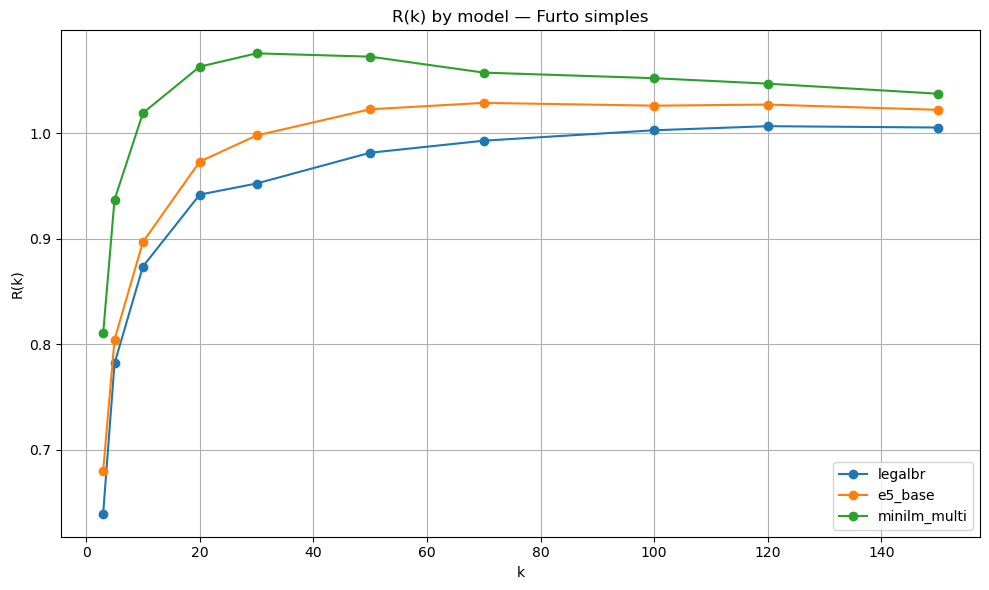

In [15]:
for crime in TARGET_CRIMES:
    df_plot = df_metrics[
        df_metrics["crime"] == crime
    ]

    if df_plot.empty:
        continue

    plt.figure(figsize=(10, 6))

    for model_id in ACTIVE_MODELS:
        data = df_plot[
            df_plot["model_id"] == model_id
        ].sort_values("k")

        if data.empty:
            continue

        plt.plot(
            data["k"],
            data["R_k"],
            marker="o",
            label=model_id,
        )

    plt.xlabel("k")
    plt.ylabel("R(k)")
    plt.title(
        f"R(k) by model — {crime}"
    )
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## 15. MAE Curves

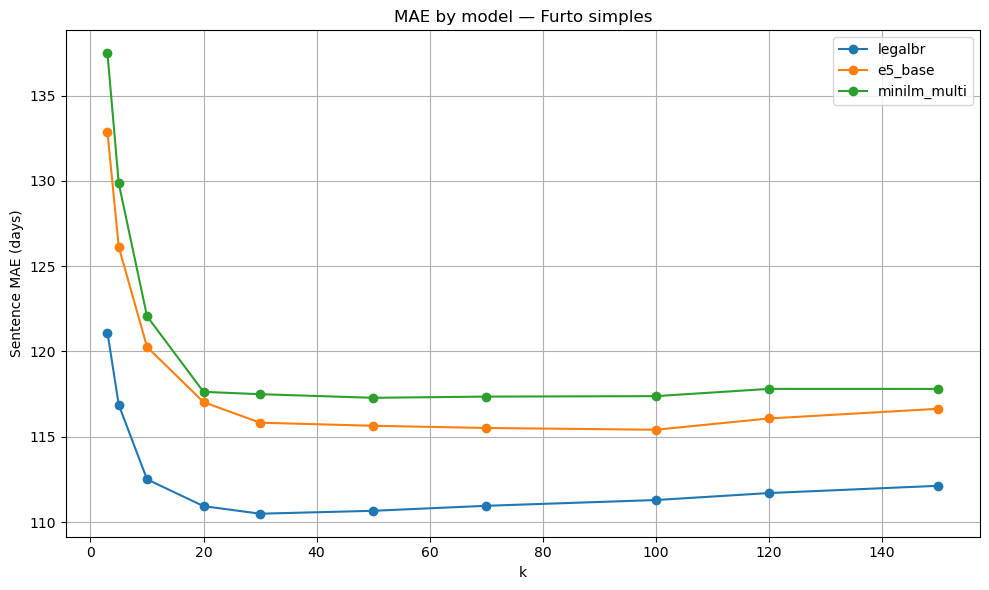

In [16]:
for crime in TARGET_CRIMES:
    df_plot = df_metrics[
        df_metrics["crime"] == crime
    ]

    if df_plot.empty:
        continue

    plt.figure(figsize=(10, 6))

    for model_id in ACTIVE_MODELS:
        data = df_plot[
            df_plot["model_id"] == model_id
        ].sort_values("k")

        if data.empty:
            continue

        plt.plot(
            data["k"],
            data["MAE_days"],
            marker="o",
            label=model_id,
        )

    plt.xlabel("k")
    plt.ylabel("Sentence MAE (days)")
    plt.title(
        f"MAE by model — {crime}"
    )
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## 16. Computational Table for the Article

This table combines model characteristics with inference cost.

For a valid timing comparison:

- timing coverage should be close to 100% for all models;
- all models should be run on the same machine;
- no other substantial GPU workload should run during measurement;
- initial model download time is not included in per-judgment inference time.

In [ ]:
paper_computational_table = performance_table[
    [
        "model_id",
        "parameters_millions",
        "parameter_size_mb",
        "embedding_dimension",
        "max_seq_length",
        "total_inference_time_s",
        "mean_time_per_doc_s",
        "docs_per_minute",
        "peak_vram_current_run_mb",
        "timing_coverage_pct",
    ]
].copy()

paper_computational_table.to_csv(
    OUTPUT_DIR / "paper_computational_table.csv",
    index=False,
)

paper_computational_table.round(2)

# Methodological Notes

For replication of the original undergraduate-thesis experiment, the initial configuration used:

- the dataset label `Furto simples`;
- `PCA_COMPONENTS = 100`;
- the same values of `k` used in the thesis.

After confirming that `legalbr` approximately reproduced the previous experiment, the article extension evaluated additional models and also considered the original embedding spaces without PCA.

This separation makes it possible to distinguish **replication of the undergraduate thesis** from the **article extension** and to interpret differences introduced by the new protocol.